In [1]:
import os
from typing import List, Optional, Tuple, Iterable
import random

import cv2
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from pycocotools import mask as maskUtils
import supervision as sv
import matplotlib.pyplot as plt


from IPython.display import Video, display

In [2]:
pq_path = (
    "../sandbox/output/grounded-sam-2/output-15-sec_2/test-img-15-sec_large.parquet"
)
df = pd.read_parquet(pq_path)
df

size                                             counts                  bbox class     score
frame object_id                                                                                                     
0     1          [576, 704]  R`Q82la05L3M3N2M3M4K6K6K3M3L5L3M2N2N2N2N101N2N...  [457, 440, 537, 526]  bird  0.334589
      2          [576, 704]  nWX11ma03O1O0O2O000010O00000000000000010O00000...   [71, 315, 144, 352]  None  0.252384
      3          [576, 704]  iTo35ia03N1O1O100O001O1O001000000O010000O2N1N3...    [226, 14, 247, 30]  None  0.299925
      4          [576, 704]  Ymj9m0Pa05L4J5F:I7M3M2O2L3O2M2O1O2M2O1N2O1N2O1...  [559, 421, 605, 528]  None  0.255344
      5          [576, 704]  m]P9<`a07H8I6H8H8I6K6J4N3N3M2N2O1N2O1O1O2N100O...  [512, 401, 564, 519]  None  0.284576
...                     ...                                                ...                   ...   ...       ...
373   1          [576, 704]  ]nZ12na02M3M3L4J7L3N1O2O0O2N101N3N3M3M4L2N3M3M...   [76, 196, 183, 321]  bird  0.334589
      2          [576, 704]  kiX14ka02O1O010O10O01O010O01000O10O010O10O1000...   [72, 314, 126, 380]  None  0.252384
      3          [576, 704]  lTo33ka04L2O1O1O1O001O010O1O0100000001N100O1O2...    [226, 16, 247, 32]  None  0.299925
      4          [576, 704]  ajk84ha05O0LI^^O8ba04_^OC[a0f0L0ON21m^O[O1000W...  [504, 289, 571, 386]  None  0.255344
      5          [576, 704]  QhS3<aa06K6J5K4L5K4L4L4L4M3M3M3M3M3M3M3N1N2N3N...  [177, 151, 237, 266]  None  0.284576

[1870 rows x 5 columns]

In [ ]:
# --- USER CONFIG ---
FRAMES_DIR = "../data/test-img-15-sec"  # folder with images like 00001.jpg
FRAME_EXT = "jpg"  # or "png" etc.
OUTPUT_VIDEO = "../sandbox/output/grounded-sam-2/output-15-sec_2/video_gen_from_df.mp4"
FPS: Optional[float] = 25.0
MASK_OPACITY = 0.4
BBOX_OPACITY = 0.2
TEXT_SCALE = 0.6
# -------------------

# Helpful checks
assert os.path.isdir(FRAMES_DIR), f"Frames dir does not exist: {FRAMES_DIR}"

# If you used (frame_id, object_id) in the MultiIndex, rename to ('frame','object_id') once:
try:
    if df.index.names != ["frame", "object_id"]:
        df.index = df.index.set_names(["frame", "object_id"])
except Exception as e:
    raise ValueError(
        "Please ensure your DataFrame index is a MultiIndex with levels ('frame','object_id')."
    ) from e

# Sanity check columns
required_cols = {"size", "counts", "bbox", "class", "score"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Your DataFrame is missing columns: {missing}")

In [ ]:
def frame_path(FRAMES_PATH: str, frame_id: int) -> Optional[str]:
    """Return path to padded frame file like 00001.jpg or None if missing."""
    p = os.path.join(FRAMES_DIR, f"{int(frame_id):05d}.{FRAME_EXT}")
    return p if os.path.exists(p) else None


def to_xyxy(bbox_xywh: List[float]) -> np.ndarray:
    x, y, w, h = bbox_xywh
    return np.array([x, y, x + w, y + h], dtype=np.float32)


def decode_rle(size_hw: List[int], counts) -> np.ndarray:
    """
    Decode COCO RLE (compressed string or uncompressed list) into a boolean mask (H, W).
    `size_hw` must be [H, W].
    """
    h, w = int(size_hw[0]), int(size_hw[1])
    if isinstance(counts, str):
        rle = {"size": [h, w], "counts": counts.encode("utf-8")}
    elif isinstance(counts, (list, tuple)):
        rle = {"size": [h, w], "counts": counts}
    else:
        raise TypeError(
            "Unsupported RLE 'counts' type. Must be str (compressed) or list (uncompressed)."
        )

    mask = maskUtils.decode(rle)  # returns uint8 {0,1}
    if mask.shape != (h, w):
        raise ValueError(f"Decoded mask shape {mask.shape} != expected {(h, w)}")
    return mask.astype(bool)


def compute_xyxy_from_mask(mask_bool: np.ndarray) -> np.ndarray:
    """Fallback box from mask if bbox is None: returns [x1,y1,x2,y2] or tiny box if empty."""
    ys, xs = np.where(mask_bool)
    if len(xs) == 0 or len(ys) == 0:
        return np.array([0, 0, 1, 1], dtype=np.float32)
    x1, y1, x2, y2 = xs.min(), ys.min(), xs.max() + 1, ys.max() + 1
    return np.array([x1, y1, x2, y2], dtype=np.float32)


def make_class_maps(df: pd.DataFrame):
    """Build class<->id maps from df['class']."""
    unique = [c for c in pd.Series(df["class"]).dropna().unique().tolist()]
    class_to_id = {c: i for i, c in enumerate(sorted(unique))}
    id_to_class = {i: c for c, i in class_to_id.items()}
    return class_to_id, id_to_class


CLASS_TO_ID, ID_TO_CLASS = make_class_maps(df)


def detections_from_frame_df(df_frame: pd.DataFrame) -> sv.Detections:
    """
    Build a supervision.Detections from a per-frame sub-DataFrame (index: object_id).
    Expects df_frame columns: size, counts, bbox, class, score
    """
    xyxy_list, masks, class_ids, confidences, tracker_ids = [], [], [], [], []

    for object_id, row in df_frame.sort_index().iterrows():
        size_hw = row["size"]
        counts = row["counts"]
        bbox = row["bbox"]
        cls_name = row["class"]
        score = float(row["score"]) if row.get("score", None) is not None else 1.0

        # Decode mask
        mask_bool = decode_rle(size_hw, counts)
        masks.append(mask_bool)

        # BBox: use provided, else derive from mask
        if bbox is not None and not (isinstance(bbox, float) and np.isnan(bbox)):
            xyxy = to_xyxy(bbox)
        else:
            xyxy = compute_xyxy_from_mask(mask_bool)
        xyxy_list.append(xyxy)

        # Class id & metadata
        cid = CLASS_TO_ID.get(cls_name, -1)
        class_ids.append(cid)
        confidences.append(score)
        tracker_ids.append(int(object_id))

    xyxy_arr = np.vstack(xyxy_list) if xyxy_list else np.zeros((0, 4), dtype=np.float32)
    masks_arr = np.stack(masks, axis=0) if masks else np.zeros((0, 1, 1), dtype=bool)
    class_ids_arr = (
        np.array(class_ids, dtype=np.int32)
        if class_ids
        else np.zeros((0,), dtype=np.int32)
    )
    confidences_arr = (
        np.array(confidences, dtype=np.float32)
        if confidences
        else np.zeros((0,), dtype=np.float32)
    )
    tracker_ids_arr = (
        np.array(tracker_ids, dtype=np.int32)
        if tracker_ids
        else np.zeros((0,), dtype=np.int32)
    )

    return sv.Detections(
        xyxy=xyxy_arr,
        mask=masks_arr,
        class_id=class_ids_arr,
        confidence=confidences_arr,
        tracker_id=tracker_ids_arr,
    )


def annotate_frame(
    img_bgr: np.ndarray,
    detections: sv.Detections,
    *,
    exclude_ids: Optional[Iterable[int]] = None,
    only_ids: Optional[Iterable[int]] = None,
) -> np.ndarray:
    """
    Draw masks and labels on BGR image.
    - Colors are stable per track id (object_id).
    - You can pass `exclude_ids` to filter OUT those object ids.
    - Or `only_ids` to keep ONLY those object ids (takes precedence if both set).
    """
    # ----- filter by object ids -----
    if len(detections) == 0:
        return img_bgr.copy()

    # Ensure we have tracker ids to filter on
    if detections.tracker_id is not None:
        tids = detections.tracker_id
    else:
        # No tracker ids present -> nothing to filter by
        tids = None

    keep_mask = np.ones(len(detections), dtype=bool)

    if tids is not None:
        tids_arr = np.array(
            [int(t) if t is not None else -1 for t in tids], dtype=np.int64
        )

        if only_ids is not None:
            only_set = set(int(x) for x in only_ids)
            keep_mask &= np.isin(tids_arr, list(only_set))
        elif exclude_ids is not None:
            excl_set = set(int(x) for x in exclude_ids)
            keep_mask &= ~np.isin(tids_arr, list(excl_set))

        detections = detections[keep_mask]

    # If everything was filtered out, return original image
    if len(detections) == 0:
        return img_bgr.copy()

    # ----- build labels -----
    labels = []
    n = len(detections)
    for i in range(n):
        tid = int(detections.tracker_id[i]) if detections.tracker_id is not None else -1
        conf = (
            float(detections.confidence[i])
            if detections.confidence is not None
            else 1.0
        )
        labels.append(f"ID {tid} | {conf:.2f}")

    # ----- ensure masks match image size -----
    if detections.mask is not None and len(detections) > 0:
        H_img, W_img = img_bgr.shape[:2]
        H_m, W_m = detections.mask.shape[1:3]
        if (H_img, W_img) != (H_m, W_m):
            resized = []
            for m in detections.mask:
                m8 = m.astype(np.uint8) * 255
                m8 = cv2.resize(m8, (W_img, H_img), interpolation=cv2.INTER_NEAREST)
                resized.append(m8.astype(bool))
            # `model_copy` is available in supervision>=0.18; if older, use slicing/indexing to rebuild
            detections = detections.model_copy(
                update={"mask": np.stack(resized, axis=0)}
            )

    # ----- annotators -----
    mask_annotator = sv.MaskAnnotator(
        opacity=MASK_OPACITY, color_lookup=sv.ColorLookup.TRACK
    )
    label_annotator = sv.LabelAnnotator(
        text_scale=TEXT_SCALE, text_thickness=1, color_lookup=sv.ColorLookup.TRACK
    )

    canvas = mask_annotator.annotate(scene=img_bgr.copy(), detections=detections)
    canvas = label_annotator.annotate(
        scene=canvas, detections=detections, labels=labels
    )
    return canvas


def visualise_frame(
    frames_path: str, preview_frame_int: int, df: pd.DataFrame, **kwargs
):
    exclude_ids = kwargs.get("exclude_ids")
    """Quick preview on a single frame"""
    img_path = frame_path(frames_path, preview_frame_int)
    if img_path is None:
        raise FileNotFoundError(
            f"No image found for frame {preview_frame_int} -> {preview_frame_int:05d}.{FRAME_EXT}"
        )

    img = cv2.imread(img_path, cv2.IMREAD_COLOR)
    assert img is not None, f"Failed to read {img_path}"

    df_frame = df.loc[preview_frame_int]  # index is object_id
    dets = detections_from_frame_df(df_frame)
    annotated = annotate_frame(img, dets, exclude_ids=exclude_ids)

    # Show (RGB in matplotlib)
    plt.figure(figsize=(10, 6))
    plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    plt.title(f"Frame {preview_frame:05d}")
    plt.axis("off")
    plt.show()

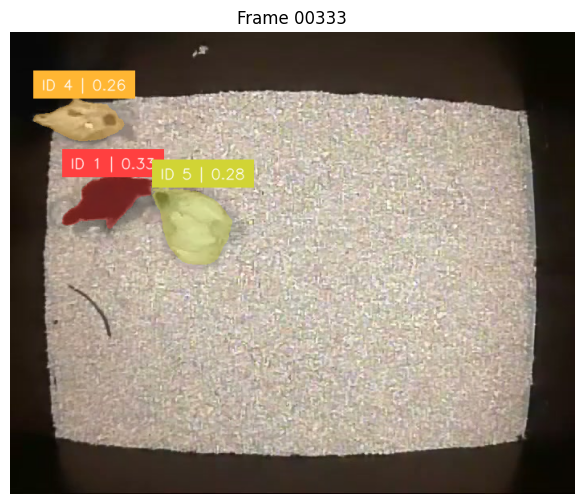

In [ ]:
# Pick a random or specific frame with annotations
frame_ids = sorted(df.index.get_level_values("frame").unique().tolist())
# preview_frame = random.choice(frame_ids)  # or set e.g. 101
preview_frame = 333  # or set e.g. 101

visualise_frame(FRAMES_DIR, preview_frame, df, exclude_ids=[2, 3])

In [ ]:
# Determine frame size and FPS
first_path = None
for fr in frame_ids:
    p = frame_path(FRAMES_DIR, fr)
    if p is not None:
        first_path = p
        break

if first_path is None:
    raise FileNotFoundError(
        "No frame images found that match the zero-padded naming like 00001.jpg"
    )

first_img = cv2.imread(first_path, cv2.IMREAD_COLOR)
assert first_img is not None, f"Failed to read first image: {first_path}"
H, W = first_img.shape[:2]
fps_local = float(FPS if FPS is not None else 30.0)

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(OUTPUT_VIDEO, fourcc, fps_local, (W, H))
if not writer.isOpened():
    raise RuntimeError(f"Failed to open VideoWriter for {OUTPUT_VIDEO}")

for frame_id, df_frame in tqdm(
    df.groupby(level="frame", sort=True), total=len(frame_ids), desc="Rendering"
):
    # Drop the outer index level so index is object_id
    df_frame = df_frame.droplevel("frame")

    img_path = frame_path(FRAMES_DIR, frame_id)
    if img_path is None:
        # If the image is missing, skip this frame
        continue

    img = cv2.imread(img_path, cv2.IMREAD_COLOR)
    if img is None:
        continue

    dets = detections_from_frame_df(df_frame)
    annotated = annotate_frame(img, dets, exclude_ids=[2, 3])
    writer.write(annotated)

writer.release()
print(f"Saved video to: {OUTPUT_VIDEO}")


Rendering: 100%|██████████| 374/374 [00:02<00:00, 133.69it/s]


Saved video to: ../sandbox/output/grounded-sam-2/output-15-sec_2/video_gen_from_df.mp4


# Merge with ethogram

In [21]:
# ethogram_ids = ["C1G1 2664 ", "C1G1 2670", "C1G1 2780"]
ethogram_ids = {
    "C1G1 2664 ": "White, blue head",
    "C1G1 2670": "Black",
    "C1G1 2780": "White, black head",
}
etho_df_dict = pd.read_excel(
    "../data/Registration protocols.xlsx",
    sheet_name=list(ethogram_ids.keys()),
    skiprows=[0],
    skipfooter=1,
)

In [22]:
etho_df_dict.keys()

dict_keys(['C1G1 2664 ', 'C1G1 2670', 'C1G1 2780'])

black : object id 1
white, blue : object id 4
white, black : object id 5

In [36]:
ids = [
    ["C1G1 2664", "White, blue head", 4],
    ["C1G1 2670", "Black", 1],
    ["C1G1 2780", "White, black head", 5],
]
individual_name_map = pd.DataFrame(
    data=ids, columns=["ethogram_name", "nat_name", "obj_name"]
)
individual_name_map

,ethogram_name,nat_name,obj_name
0,C1G1 2664,"White, blue head",4
1,C1G1 2670,Black,1
2,C1G1 2780,"White, black head",5


In [28]:
print(individual_name_map)

  ethogram_name           nat_name  obj_name
0     C1G1 2664   White, blue head         4
1     C1G1 2670              Black         1
2     C1G1 2780  White, black head         5


In [ ]:
df_merged = pd.DataFrame()

for key, value in etho_df_dict.items():
    print(key)
    df_tmp = value

    # Sanitise column names
    df_tmp.columns = [str(col).strip() for col in df_tmp.columns]

    # Get timestamps
    df_tmp["timestamp"] = pd.to_timedelta(
        df_tmp["min"] - 1, unit="min"
    ) + pd.to_timedelta(df_tmp["sek"], unit="s")

    # Get actions
    actions_cols = [x.strip() for x in df_tmp.columns if x not in ["min", "sek"]]

    actions_ohe = (
        df_tmp[actions_cols]
        .apply(pd.to_numeric, errors="coerce")  # convert invalid strings to NaN
        .fillna(0)
        .astype(int)
    )
    actions_flat = actions_ohe.apply(lambda row: "/".join(row.index[row == 1]), axis=1)
    df_tmp["action"] = actions_flat

    # Get object ID, merge
    obj_id = individual_name_map.loc[
        individual_name_map["ethogram_name"] == key.strip(), "obj_name"
    ].iloc[0]
    df_tmp["object_id"] = [obj_id for _ in range(len(df_tmp))]

    df_merged = pd.concat([df_merged, df_tmp])


# df_merged["timestamp_str"] = (
#     df_merged["timestamp"]
#     .dt.total_seconds()
#     .apply(
#         lambda s: f"{int(s // 3600):02d}:{int((s % 3600) // 60):02d}:{int(s % 60):02d}"
#     )
# )
df_merged["timestamp_str"] = df_merged["timestamp"].dt.to_pytimedelta().astype(str)

df_merged = df_merged[["object_id", "timestamp", "timestamp_str", "action"]]
df_merged
df

C1G1 2664 
C1G1 2670
C1G1 2780


,object_id,timestamp,timestamp_str,action
0,4,0 days 00:00:05,0:00:05,
1,4,0 days 00:00:10,0:00:10,Frolicking
2,4,0 days 00:00:15,0:00:15,Frolicking
3,4,0 days 00:00:20,0:00:20,
4,4,0 days 00:00:25,0:00:25,Frolicking
...,...,...,...,...
175,5,0 days 00:14:40,0:14:40,
176,5,0 days 00:14:45,0:14:45,
177,5,0 days 00:14:50,0:14:50,
178,5,0 days 00:14:55,0:14:55,
